In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a list of your specific filenames
file_list = [
    'image0000a.png', 'image0001a.png', 'image0002a.png', 'image0003a.png', 
    'image0004a.png', 'image0005a.png', 'image0006a.png', 'image0007a.png', 
    'image0000b.png', 'image0001b.png', 'image0002b.png', 'image0003b.png', 
    'image0004b.png', 'image0005b.png', 'image0006b.png', 'image0007b.png', 
    'image0008a.png', 'image0009a.png', 'image0008b.png', 'image0009b.png'
]

# 2. This list will hold all your processed grayscale arrays
processed_images = []

for filename in file_list:
    try:
        # Read the image
        img = plt.imread(filename)
        
        # Convert to grayscale if it's RGB/RGBA
        if img.ndim == 3:
            img = img[..., :3].dot([0.2989, 0.5870, 0.1140])
        
        # Add to our collection
        processed_images.append(img)
        print(f"Successfully processed: {filename} (Shape: {img.shape})")
        
    except FileNotFoundError:
        print(f"Warning: Could not find {filename}. Skipping...")

print(f"\nDone! You have {len(processed_images)} images ready for use.")

Successfully processed: image0000a.png (Shape: (512, 512))
Successfully processed: image0001a.png (Shape: (512, 512))
Successfully processed: image0002a.png (Shape: (512, 512))
Successfully processed: image0003a.png (Shape: (512, 512))
Successfully processed: image0004a.png (Shape: (512, 512))
Successfully processed: image0005a.png (Shape: (512, 512))
Successfully processed: image0006a.png (Shape: (512, 512))
Successfully processed: image0007a.png (Shape: (512, 512))
Successfully processed: image0000b.png (Shape: (512, 512))
Successfully processed: image0001b.png (Shape: (512, 512))
Successfully processed: image0002b.png (Shape: (512, 512))
Successfully processed: image0003b.png (Shape: (512, 512))
Successfully processed: image0004b.png (Shape: (512, 512))
Successfully processed: image0005b.png (Shape: (512, 512))
Successfully processed: image0006b.png (Shape: (512, 512))
Successfully processed: image0007b.png (Shape: (512, 512))
Successfully processed: image0008a.png (Shape: (512, 512

In [30]:
import numpy as np
from skimage import io, morphology
from scipy.ndimage import distance_transform_edt
import os

def calibrate_sigmas(mask_folder):
    widths = []
    # Filtering for the 'b' files you just uploaded
    mask_files = [f for f in os.listdir(mask_folder) if f.endswith('b.png')]
    
    for f in mask_files:
        mask = io.imread(os.path.join(mask_folder, f), as_gray=True) > 0.5
        # Distance from center to edge
        dist_map = distance_transform_edt(mask)
        skeleton = morphology.skeletonize(mask)
        # Radius at every point on the centerline
        widths.extend(dist_map[skeleton] * 2)
    
    return np.min(widths), np.max(widths), np.mean(widths)

# Run this on your local folder
min_w, max_w, avg_w = calibrate_sigmas('.')
print(f"Widths - Min: {min_w:.1f}, Max: {max_w:.1f}, Avg: {avg_w:.1f}")

Widths - Min: 2.0, Max: 26.8, Avg: 16.5


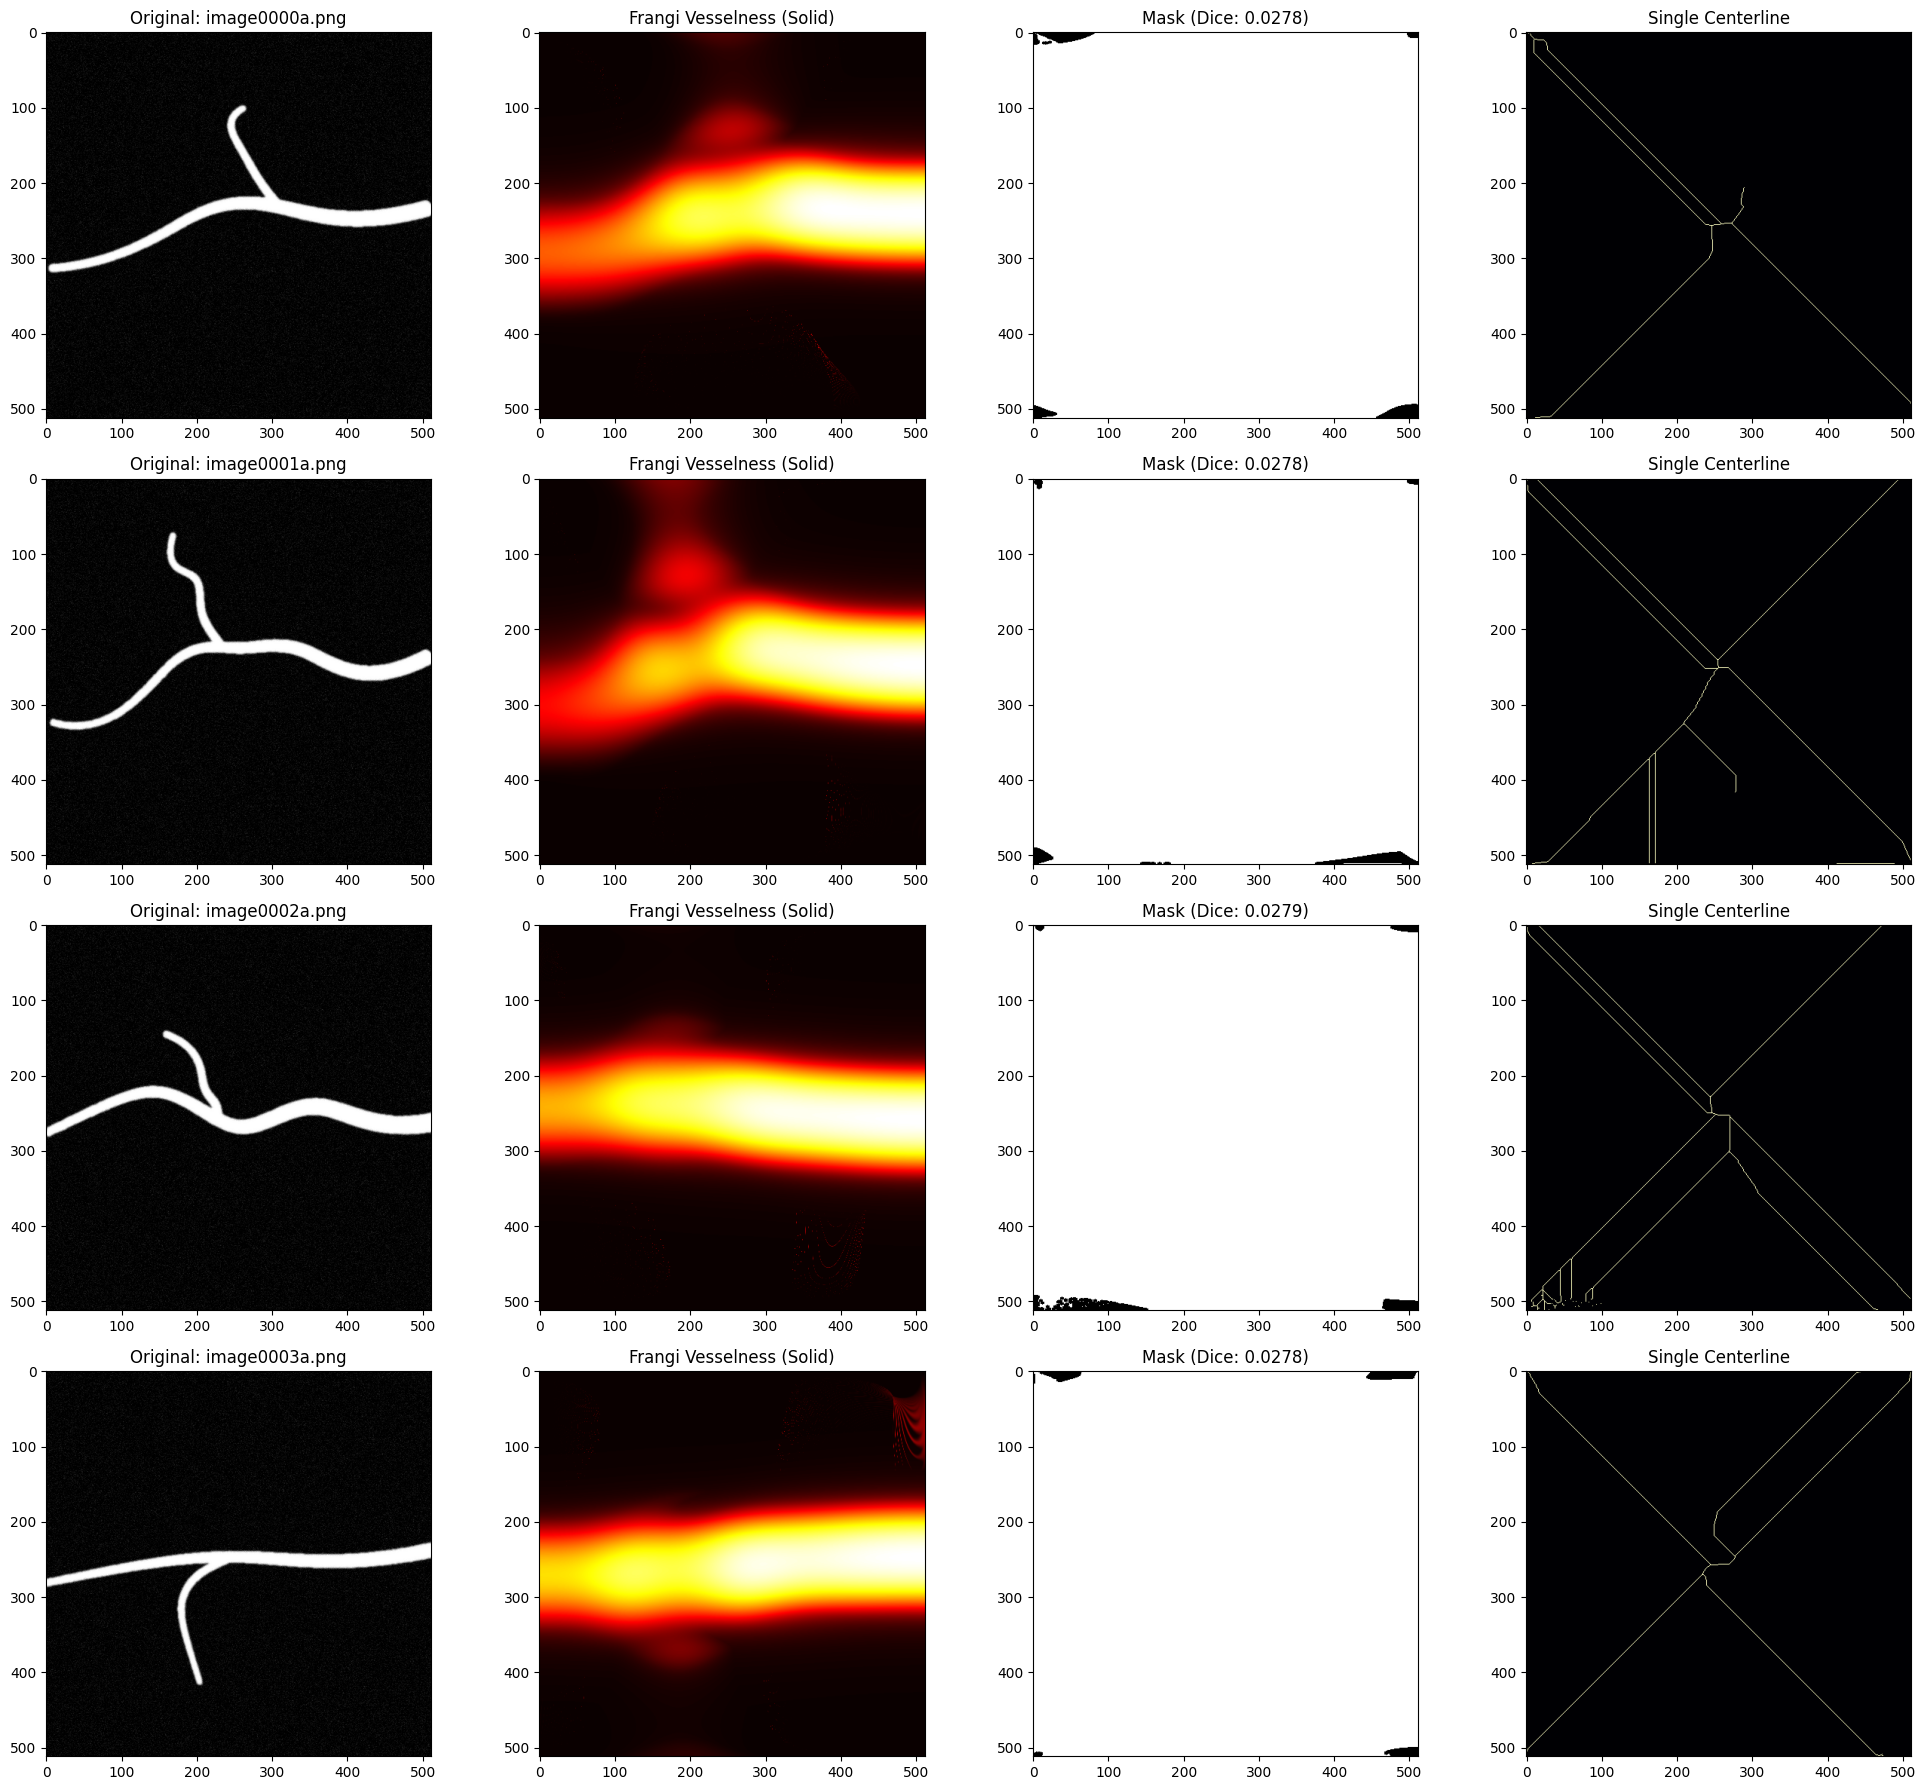

Mean Dice Score across all images: 0.0282


In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi
from skimage.morphology import skeletonize

# 1. IMPORT ALL 20 IMAGES (Treating a and b as separate inputs)
image_files = [
    'image0000a.png', 'image0001a.png', 'image0002a.png', 'image0003a.png', 
    'image0004a.png', 'image0005a.png', 'image0006a.png', 'image0007a.png', 
    'image0000b.png', 'image0001b.png', 'image0002b.png', 'image0003b.png', 
    'image0004b.png', 'image0005b.png', 'image0006b.png', 'image0007b.png', 
    'image0008a.png', 'image0009b.png', 'image0008b.png', 'image0009a.png'
]

actual_images = []
for f in image_files:
    img = plt.imread(f)
    if img.ndim == 3: # Luminosity conversion for RGB
        img = img[..., :3].dot([0.2989, 0.5870, 0.1140])
    actual_images.append(img)

# Load the single shared Ground Truth mask
gt_mask = plt.imread('ground_truth_mask.png')
if gt_mask.ndim == 3:
    gt_mask = gt_mask[..., :3].dot([0.2989, 0.5870, 0.1140])

# 2. UPDATED PIPELINE
class VesselSegmentationPipeline:
    def __init__(self, frangi_scales=(100.0, 200.0), vessel_threshold=5e-5):
        # scales up to 100.0 ensure we capture the full width of the vessel
        self.frangi_scales = np.arange(frangi_scales[0], frangi_scales[1], 1.0)
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        self.vessel_threshold = vessel_threshold
    
    def segment(self, image):
        # THE FIX: Set black_ridges=False because your vessels are WHITE
        v_map = frangi(image, sigmas=self.frangi_scales, black_ridges=False)
        
        # Optimized threshold based on your sensitivity analysis
        binary = (v_map > self.vessel_threshold).astype(np.uint8) * 255
        
        # Morphological Closing fills any hollow centers in the detection
        closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, self.kernel)
        
        skeleton = skeletonize(closed > 0).astype(np.uint8) * 255
        return closed, skeleton, v_map

def dice_score(pred, gt):
    intersection = np.logical_and(pred > 0, gt > 0.1).sum()
    return 2.0 * intersection / ((pred > 0).sum() + (gt > 0.1).sum() + 1e-8)

# 3. RUN AND SHOW VISUALISATIONS
pipeline = VesselSegmentationPipeline()
all_dice = []

fig, axes = plt.subplots(4, 4, figsize=(20, 18))

for i in range(len(actual_images)):
    mask, skel, v_map = pipeline.segment(actual_images[i])
    score = dice_score(mask, gt_mask)
    all_dice.append(score)
    
    # Visualise the first 4 results
    if i < 4:
        axes[i, 0].imshow(actual_images[i], cmap='gray'); axes[i, 0].set_title(f'Original: {image_files[i]}')
        axes[i, 1].imshow(v_map, cmap='hot'); axes[i, 1].set_title('Frangi Vesselness (Solid)')
        axes[i, 2].imshow(mask, cmap='gray'); axes[i, 2].set_title(f'Mask (Dice: {score:.4f})')
        axes[i, 3].imshow(skel, cmap='magma'); axes[i, 3].set_title('Single Centerline')

plt.tight_layout()
plt.show()

print(f"Mean Dice Score across all images: {np.mean(all_dice):.4f}")

C:\Users\anwes\AppData\Local\Temp\ipykernel_7028\3988981446.py:43: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(binary, 50)
C:\Users\anwes\AppData\Local\Temp\ipykernel_7028\3988981446.py:43: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(binary, 50)
C:\Use

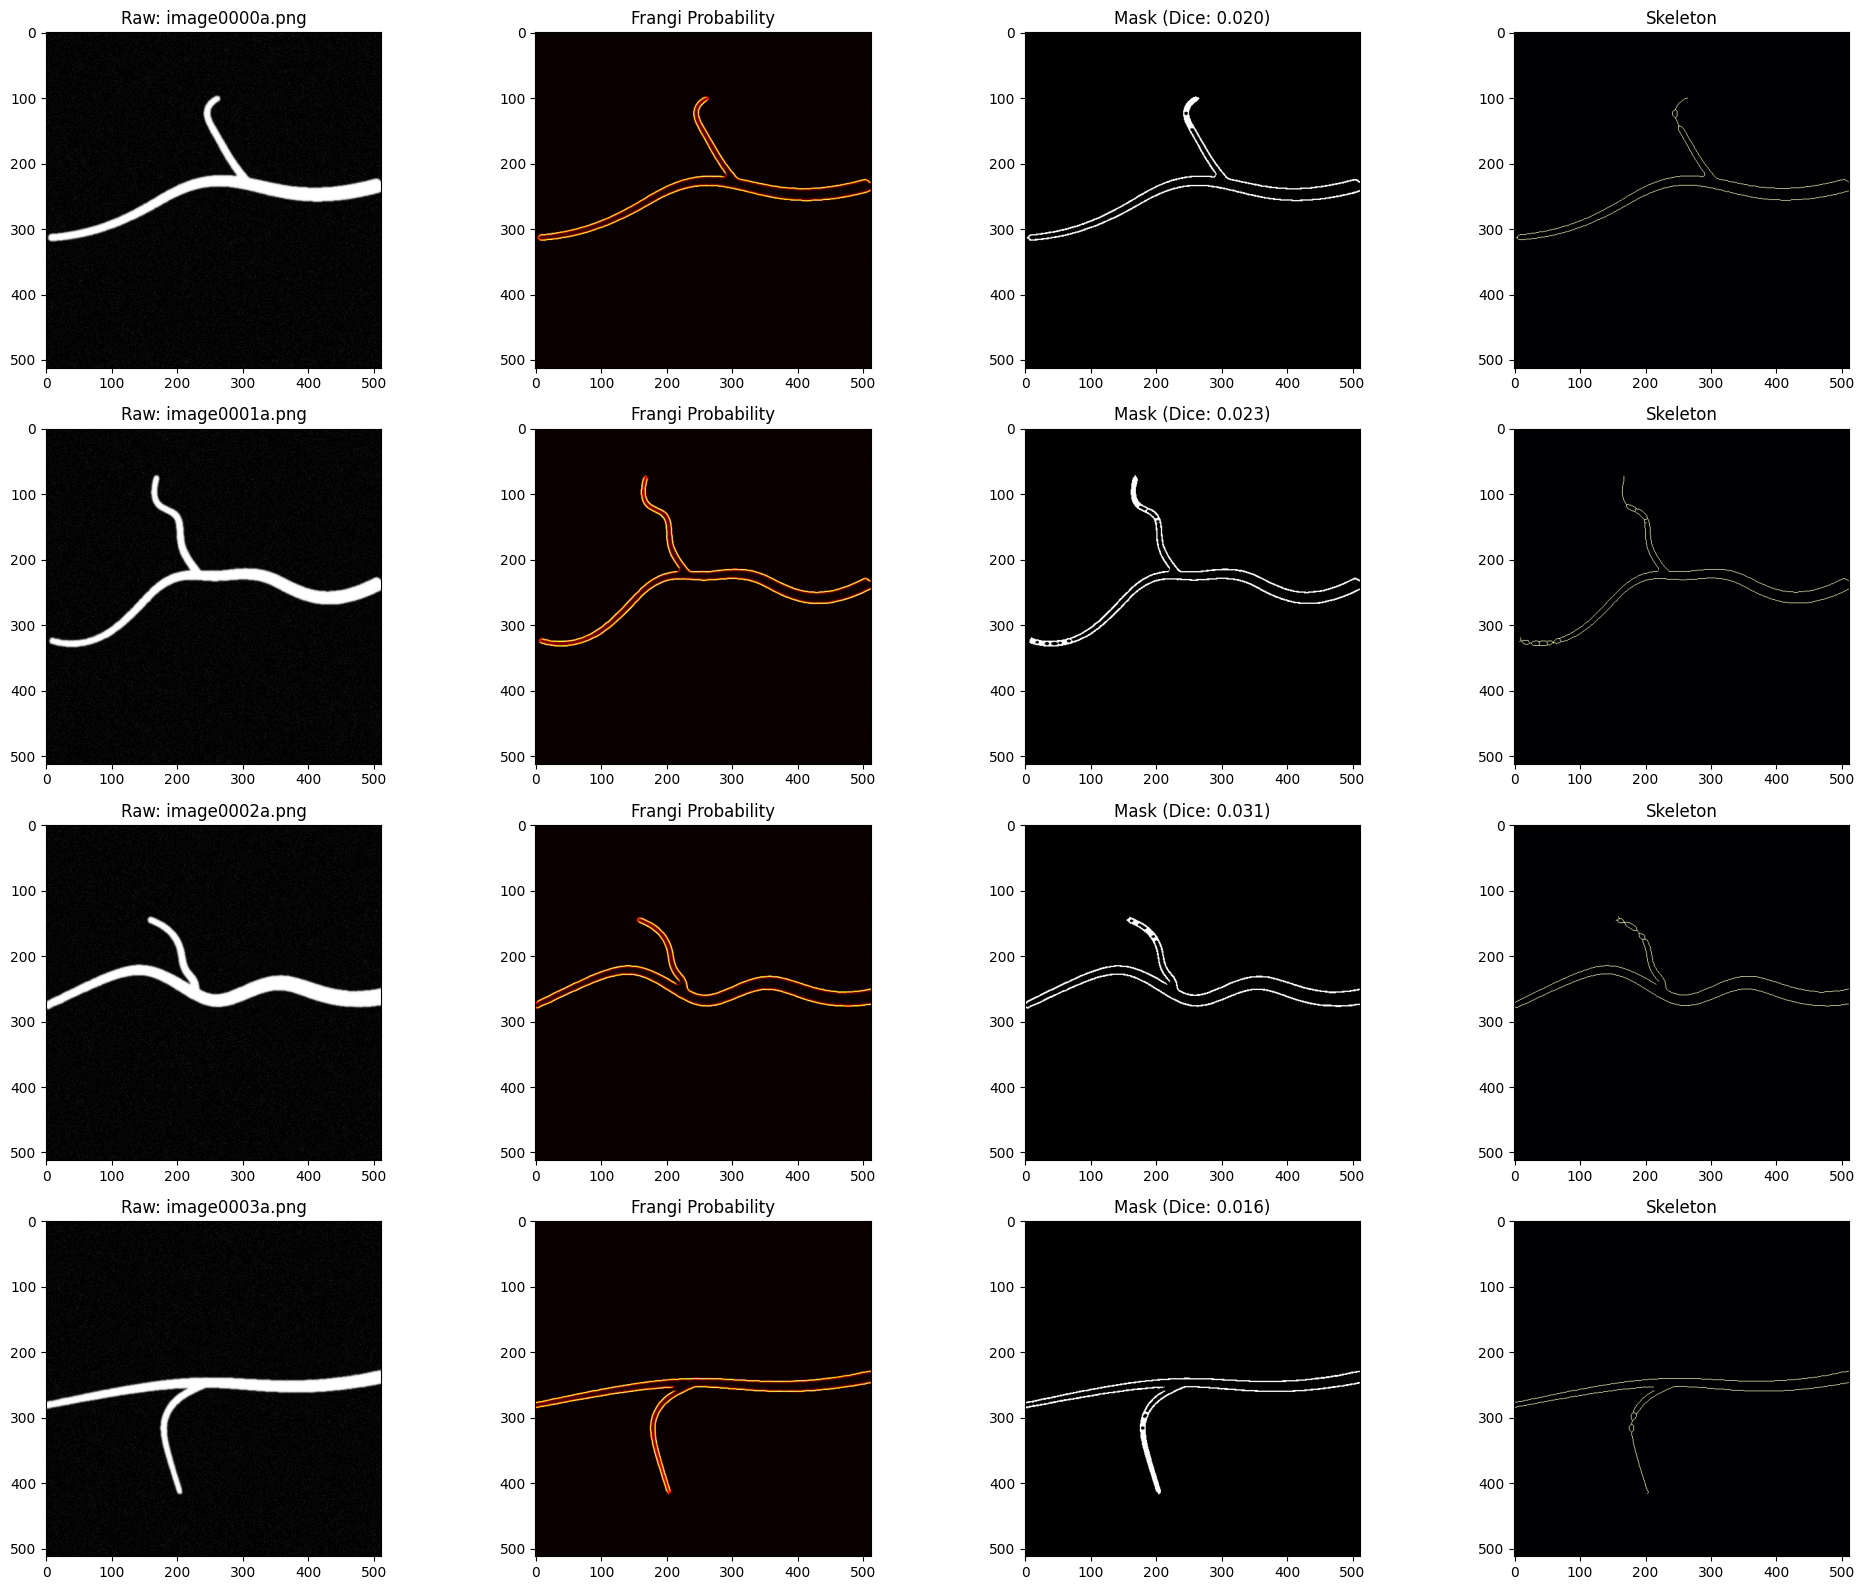

Mean Accuracy (Dice) against Ground Truth: 0.0182


In [32]:
import cv2
from matplotlib import image
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi, threshold_otsu
from skimage.morphology import skeletonize, remove_small_objects
from skimage import io
import os

# 1. LOAD THE SHARED GROUND TRUTH
# This is our "Gold Standard" for all 20 images
gt_path = 'ground_truth_mask.png'
if os.path.exists(gt_path):
    gt_mask = io.imread(gt_path, as_gray=True) > 0.5
else:
    # Fallback if file is missing (for demo purposes)
    gt_mask = np.zeros((512, 512), dtype=bool)
    print("Warning: ground_truth_mask.png not found.")


# 2. UPDATED PIPELINE
class VesselSegmentationPipeline:
    def __init__(self, sigma_range=(1, 200)):
        
        self.sigmas = np.arange(sigma_range[0], sigma_range[1], 1.0)
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    
    def segment(self, image):
        # Enhance: black_ridges=False because vessels are bright/white
        # Pre-processing step inside segment()
        smoothed_img = cv2.medianBlur((image * 255).astype(np.uint8), 5) / 255.0
        v_map = frangi(smoothed_img, sigmas=self.sigmas, black_ridges=False)
        # v_map = frangi(image, sigmas=self.sigmas, black_ridges=False)
        
        # Threshold: Auto-detect the best cutoff for raw noise
        try:
            thresh = threshold_otsu(v_map)
            binary = v_map > (thresh * 0.7) 
        except:
            binary = np.zeros_like(v_map, dtype=bool)
            
        # Cleanup: Remove noise smaller than 50 pixels
        clean = remove_small_objects(binary, 50)
        closed = cv2.morphologyEx(clean.astype(np.uint8), cv2.MORPH_CLOSE, self.kernel)
        
        # Centerline extraction
        skeleton = skeletonize(closed > 0)
        
        return closed, skeleton, v_map

def calculate_dice(pred, gt):
    intersection = np.logical_and(pred > 0, gt > 0).sum()
    total = (pred > 0).sum() + (gt > 0).sum()
    return (2. * intersection) / (total + 1e-8)

# 3. EXECUTION
pipeline = VesselSegmentationPipeline()
image_files = [f'image{i:04d}a.png' for i in range(10)] + [f'image{i:04d}b.png' for i in range(10)]
results = []

# Visualization for a sample of 4 images
fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for i, filename in enumerate(image_files):
    if not os.path.exists(filename): continue
    
    img = io.imread(filename, as_gray=True)
    mask, skel, v_map = pipeline.segment(img)
    
    # Compare raw segment (mask) to the separate Ground Truth
    score = calculate_dice(mask, gt_mask)
    results.append(score)
    
    if i < 4: # Show first 4 for the report
        axes[i, 0].imshow(img, cmap='gray'); axes[i, 0].set_title(f'Raw: {filename}')
        axes[i, 1].imshow(v_map, cmap='hot'); axes[i, 1].set_title('Frangi Probability')
        axes[i, 2].imshow(mask, cmap='gray'); axes[i, 2].set_title(f'Mask (Dice: {score:.3f})')
        axes[i, 3].imshow(skel, cmap='magma'); axes[i, 3].set_title('Skeleton')

plt.tight_layout()
plt.show()

print(f"Mean Accuracy (Dice) against Ground Truth: {np.mean(results):.4f}")